In [42]:
"""
Created on June 6, 2026
@author: Carl Emil Elling
Calculating SNR of stitched PL image
"""

import os
import cv2
import numpy as np
from tkinter import filedialog
import tifffile
from src.utils import ingaas_processing
from src import stitching
from src.stitching import helpers
import matplotlib.pyplot as plt
import scipy

def calculate_snr50_single_pixel(EL1,EL2,ELBG,px):
    #From EL standard IEC 60904-13
    # Preliminary SNR estimate in dB.
    if (EL1.size == 0 or EL2.size == 0 or ELBG.size == 0):
        raise ValueError("Cannot calculate SNR for emptyimages.")
    snr50 = np.zeros(EL1.shape[1])
    for j in range(EL1.shape[1]):
        #Sum over scan line
        snr50[j] = (0.5 * (EL1[px, j] + EL2[px, j]) - ELBG[px, j])/(abs(EL1[px, j] - EL2[px, j])*np.sqrt(0.5)*(2/np.pi**(-0.5))) 
    return 20.0 * np.log10(np.ma.masked_invalid(snr50).sum()) #avoid values where EL1(k)=EL2(k)
def plot_pixel(images,px,py):
    plt.imshow(images[px, py], cmap='gray')
    plt.show()
def load_images(source, width, height):
    if source.endswith('.raw'):
        print("Processing a .raw file")
        images = ingaas_processing.load_raw_image(source, width, height)
    elif source.endswith('.tiff'):
        print("Processing a .tiff file") 
        images = tifffile.imread(source)
    else:
        raise ValueError("Unsupported file format. Please provide a .tiff or .raw file.")
    return images



In [21]:

# Prompt user to select an image file
scan_path = "E://PLSCANNER//scans//20260602_155422//scan_20260602_155422.raw"
cal_path = "data/calibration.npz"
K,P,DIM = ingaas_processing.load_calibration(cal_path)

# Read the image using tifffile
width, height = 640, 512  # Example dimensions, adjust as necessary
scan=ingaas_processing.load_raw_image(scan_path, 640, 512)

# Calculate SNR
#snr_value = calculate_snr(images)

#print(f"SNR of the image: {snr_value:.2f} dB")


277


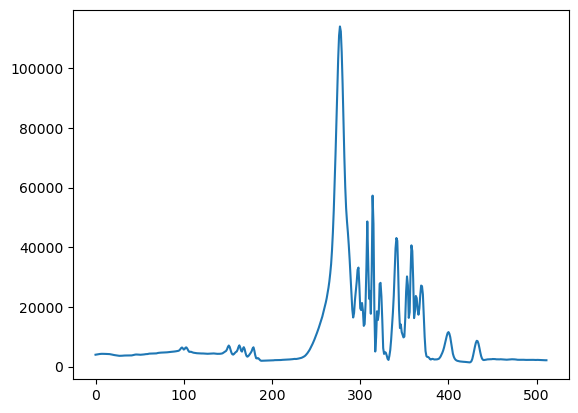

In [22]:
scan = np.array(ingaas_processing.undistort(scan, K, P, DIM))
frame_profile = np.sum(scan, axis=2)

frame_diffs = frame_profile[1:]-frame_profile[:-1]
plt.plot(np.mean(np.abs(frame_diffs), axis=0))
lom = np.argmax(np.mean(np.abs(frame_diffs), axis=0))
print(lom)

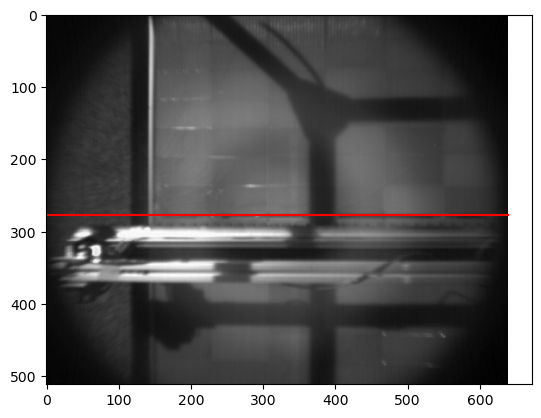

In [23]:
plt.imshow(scan[4008,:,:], cmap='gray')
plt.hlines(lom, 0, 640, "r")

In [12]:
#Functions from Jeppe
def get_phase(x, f, f_s, debug_out=False):
    '''
    Finds the phase of a given frequency in a signal, sampled at some other frequency.

    Args:
        x: The signal as a numpy array
        f: The frequency to find the phase of
        f_s: The frequency at which the signal was sampled
        debug_out: Whether to display some debug info

    Returns:
        phase: The phase of the signal
        f_out: The closest frequency present in the FFT

    '''

    # Where is the modulation frequency in the results?
    fft_frequencies = scipy.fft.fftshift(scipy.fft.rfftfreq(len(x), d=1/f_s))
    f_index = np.argmin(np.abs(f-fft_frequencies))
    f_out = fft_frequencies[f_index]
    if debug_out:
        print(f_index)
        print(f_out)

    # FFT of data
    yf = scipy.fft.fftshift(scipy.fft.rfft(x))
    if debug_out:
        plt.plot(fft_frequencies, yf)
        plt.show()


    # Get phase
    phase = np.angle(yf[f_index])
    if debug_out:
        print(yf[f_index])
        print("Phase:", phase)

    return phase, f_out

def get_extrema(f,phase,f_s,N):
    '''
    Estimate the extrema points of a discrete signal

    Args:
        f: Frequency of the signal component of interest
        phase: How the signal component is shifted. Should be in the range [-Pi,Pi]
        f_s: Frequency at which the signal is sampled
        start: Index at which to start return from
        end: Index at which to end return at

    Returns:
        peaks: Index of peaks as a numpy array
        valleys: Index of valleys as a numpy array

    '''
    peak_arg =  -phase

    if peak_arg < 0:
        peak_arg += 2*np.pi

    if peak_arg > 2*np.pi:
        peak_arg -= 2*np.pi

    valley_arg = peak_arg + np.pi

    base = np.arange(N)*2*np.pi
    peaks = np.round(f_s*(base+peak_arg)/(2*np.pi*f)).astype(np.int32)
    valleys = np.round(f_s*(base+valley_arg)/(2*np.pi*f)).astype(np.int32)

    #mask = np.all([peaks > start, peaks < end, valleys > start, valleys < end], axis=0)
    mask = np.all([peaks < N, valleys < N], axis=0)
    return peaks[mask], valleys[mask]

-2.803175304218461 49.98333333333333
[  3   9  15  21  27  33  39  45  51  57  63  69  75  81  87  93  99 105
 111 117 123 129 135 141 147 153 159 165 171 177 183 189 195 201 207 213
 219 225 231 237 243 249 255 261 267 273 279 285 291] [  6  12  18  24  30  36  42  48  54  60  66  72  78  84  90  96 102 108
 114 120 126 132 138 144 150 156 162 168 174 180 186 192 198 204 210 216
 222 228 234 240 246 252 258 264 270 276 282 288 294]


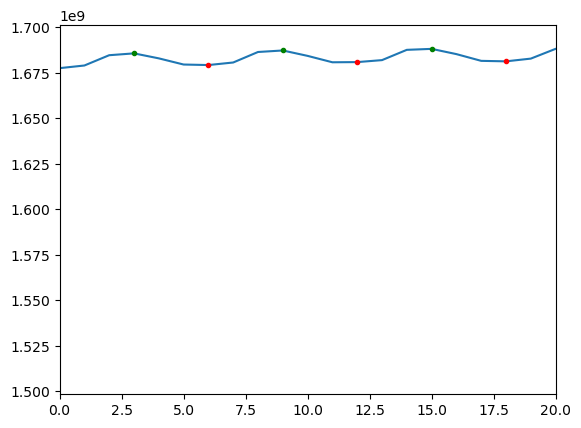

3.425692957704934
6.424692957704933


In [30]:
test = np.sum(scan, axis=(1,2))
#Parameters
f_m = 50 #Hz
#f_s = 300 #Hz
f_s = 299.9 #Hz

start = 0
wlen = round(f_s)
errors = []
phases = []
window = test[start:start + wlen]
#window = test
phase, f_out = get_phase(window, f_m, f_s)
errors.append((f_out-f_m)**2)
phases.append(phase)

print(phase,f_out)
peaks,valleys = get_extrema(f_m, phase, f_s, len(window))
print(peaks, valleys)
x_start=start
x_end=start+20

plt.plot(test)
plt.plot(peaks+start, test[peaks+start], ".g")
plt.plot(valleys+start, test[valleys+start], ".r")
plt.xlim(x_start, x_end)
plt.show()
# x = np.arange(len(test))
# y = np.sin(2*np.pi*x*f_m/f_s + phase) + np.cos(2*np.pi*x*f_m/f_s + phase)
# plt.xlim(x_start,x_end)
# plt.plot(x,y)
# plt.plot(peaks+start, y[peaks+start], ".g")
# plt.plot(valleys+start, y[valleys+start], ".r")
# plt.show()

print(f_s*(np.pi/4 - phase)/(2*np.pi*f_m))
print(f_s*(5*np.pi/4 - phase)/(2*np.pi*f_m))

In [ ]:

imgs=scan[start:,:,:]
EL1=imgs[peaks[0]]
EL2=imgs[peaks[0]-1]
ELBG=imgs[valleys[0]]
snr = calculate_snr50_single_pixel(EL1,EL2,ELBG,lom)
print(snr)

72.12627470551607


C:\Users\carle\AppData\Local\Temp\ipykernel_17536\2728104962.py:26: RuntimeWarning: divide by zero encountered in scalar divide
  snr50[j] = (0.5 * (EL1[px, j] + EL2[px, j]) - ELBG[px, j])/(abs(EL1[px, j] - EL2[px, j])*np.sqrt(0.5)*(2/np.pi**(-0.5)))


C:\Users\carle\AppData\Local\Temp\ipykernel_17536\2728104962.py:26: RuntimeWarning: divide by zero encountered in scalar divide
  snr50[j] = (0.5 * (EL1[px, j] + EL2[px, j]) - ELBG[px, j])/(abs(EL1[px, j] - EL2[px, j])*np.sqrt(0.5)*(2/np.pi**(-0.5)))
C:\Users\carle\AppData\Local\Temp\ipykernel_17536\2728104962.py:26: RuntimeWarning: invalid value encountered in scalar divide
  snr50[j] = (0.5 * (EL1[px, j] + EL2[px, j]) - ELBG[px, j])/(abs(EL1[px, j] - EL2[px, j])*np.sqrt(0.5)*(2/np.pi**(-0.5)))


73.97183073844018


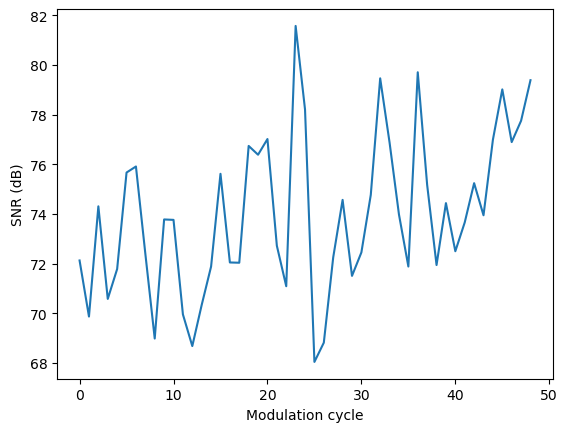

In [55]:
#Expanding to fill all modulation cycles
snr=np.zeros(len(peaks))
for i in range(len(peaks)):
    #print(i)
    EL1=imgs[peaks[i]]
    EL2=imgs[peaks[i]-1]
    ELBG=imgs[valleys[i]]
    snr[i] = calculate_snr50_single_pixel(EL1,EL2,ELBG,lom)
    
avg_snr = np.mean(snr)
print(avg_snr)
plt.plot(snr)
plt.xlabel("Modulation cycle")
plt.ylabel("SNR (dB)")
plt.show()